# 01 — Explore the Pilot Corridor Network

**Phase 0 deliverable:** load and display the Western Express Highway (Dahisar → Bandra) corridor network on a map.

This notebook loads the graph produced by `src/network/build_network.py` and visualizes it two ways:
1. A static matplotlib plot colored by road class.
2. An interactive Folium map (pan/zoom over OSM tiles).

Run `python src/network/build_network.py` first if `data/raw/osm/corridor.graphml` does not exist yet.

In [1]:
from pathlib import Path
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt

REPO_ROOT = Path.cwd().parents[0] if Path.cwd().name == 'notebooks' else Path.cwd()
GRAPHML = REPO_ROOT / 'data' / 'raw' / 'osm' / 'corridor.graphml'
print('Loading', GRAPHML)
G = ox.load_graphml(GRAPHML)
print(f'{G.number_of_nodes()} nodes, {G.number_of_edges()} edges')

Loading J:\mumbai_Traffic_Network_Planning\data\raw\osm\corridor.graphml


15106 nodes, 33788 edges


## Road-class composition

In [2]:
import collections
counts = collections.Counter()
length_km = 0.0
for u, v, d in G.edges(data=True):
    h = d.get('highway'); h = h[0] if isinstance(h, list) else h
    counts[h] += 1
    length_km += float(d.get('length', 0) or 0) / 1000
print(f'Total length: {length_km:.1f} km')
for h, c in counts.most_common():
    print(f'{h:>16}: {c}')

Total length: 2953.9 km
     residential: 20281
        tertiary: 6277
       secondary: 2723
   living_street: 1460
         primary: 1455
   tertiary_link: 476
  secondary_link: 309
           trunk: 224
    primary_link: 210
      trunk_link: 156
    unclassified: 122
   motorway_link: 52
        motorway: 42
          busway: 1


## Static map, colored by road class

Red = motorway/trunk (the WEH spine), orange = primary, yellow = secondary, gray = everything else.

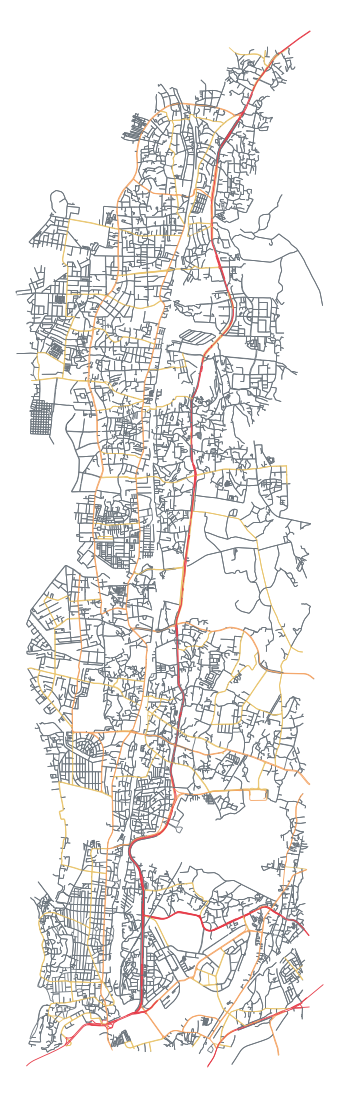

In [3]:
def edge_color(d):
    h = d.get('highway'); h = h[0] if isinstance(h, list) else h
    if h in ('motorway', 'trunk', 'motorway_link', 'trunk_link'):
        return '#e63946'
    if h in ('primary', 'primary_link'):
        return '#f4a261'
    if h in ('secondary', 'secondary_link'):
        return '#e9c46a'
    return '#6c757d'

ec = [edge_color(d) for _, _, d in G.edges(data=True)]
fig, ax = ox.plot_graph(G, node_size=0, edge_color=ec, edge_linewidth=0.6,
                        bgcolor='white', show=True, close=False, figsize=(8, 14))

## Interactive map (Folium)

Just the major roads (motorway/trunk/primary/secondary) to keep the map light.

In [4]:
major = {'motorway', 'trunk', 'motorway_link', 'trunk_link',
         'primary', 'primary_link', 'secondary', 'secondary_link'}
def is_major(d):
    h = d.get('highway'); h = h[0] if isinstance(h, list) else h
    return h in major

edges_major = [(u, v, k) for u, v, k, d in G.edges(keys=True, data=True) if is_major(d)]
Gm = G.edge_subgraph(edges_major).copy()
print(f'Major-road subgraph: {Gm.number_of_nodes()} nodes, {Gm.number_of_edges()} edges')
# osmnx 2.x: convert to a GeoDataFrame and use geopandas .explore() (Folium under the hood).
edges_gdf = ox.graph_to_gdfs(Gm, nodes=False)
cols = [c for c in ['highway', 'name', 'lanes', 'maxspeed', 'length', 'speed_kph'] if c in edges_gdf.columns]
edges_gdf[cols + ['geometry']].explore(color='#e63946', tiles='CartoDB positron',
                                        tooltip=cols, style_kwds={'weight': 2})

Major-road subgraph: 3967 nodes, 5171 edges


## Free-flow end-to-end travel time sanity check

Shortest-path travel time from the northern (Dahisar) to the southern (Bandra) end of the corridor, using the imputed free-flow `travel_time` (seconds). Compare against Google Maps off-peak (~3 AM) travel time later during calibration (Phase 3).

Free-flow route: 26.3 km, 26.7 min (imputed free-flow)


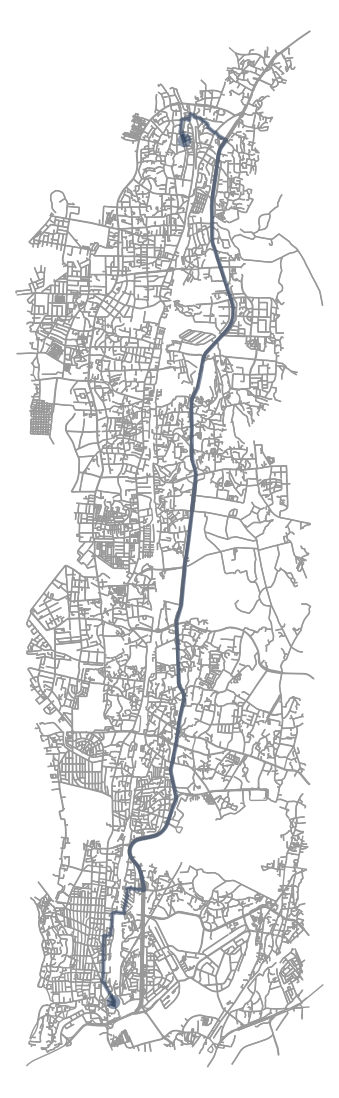

In [5]:
# Nearest graph nodes to Dahisar check naka and Bandra (approx lat/lon).
dahisar = ox.nearest_nodes(G, X=72.856, Y=19.250)
bandra = ox.nearest_nodes(G, X=72.840, Y=19.055)
route = nx.shortest_path(G, dahisar, bandra, weight='travel_time')
tt_min = nx.shortest_path_length(G, dahisar, bandra, weight='travel_time') / 60
dist_km = sum(G[u][v][0]['length'] for u, v in zip(route[:-1], route[1:])) / 1000
print(f'Free-flow route: {dist_km:.1f} km, {tt_min:.1f} min (imputed free-flow)')
fig, ax = ox.plot_graph_route(G, route, route_color='#1d3557', route_linewidth=3,
                              node_size=0, bgcolor='white', figsize=(8, 14))